https://copilot.microsoft.com/shares/1BgQxU3ouirVF7DXwR6mq


1. Data Ingestion & Storage

    Raster ingestion: Load raw satellite tiles (GeoTIFF, JP2, COGs) using rasterio or xarray.

    Metadata extraction: CRS, resolution, nodata, acquisition date.

    Chunked storage: Convert to Cloud‑Optimized GeoTIFFs or Zarr for fast chunked reads.

2. Spatial Reference & Preprocessing

    Reprojection: Ensure all rasters match the LAU layer CRS (usually EPSG:3035 or EPSG:3857).

    Resampling: Align pixel grids across scenes.

    Masking & cleaning: Apply cloud masks, QA bands, or threshold filters.

3. Vector Data Preparation

    LAU boundaries: Load LAU polygons via geopandas.

    Spatial indexing: Build R‑trees for fast tile‑to‑polygon matching.

    Geometry simplification: Optional for performance.

4. Raster–Vector Intersection

    Windowed reading: Read only the raster chunks overlapping each LAU polygon.

    Raster masking: Clip raster to each LAU boundary.

    Zonal statistics: Use rasterstats, xarray-spatial, or custom NumPy/Dask operations.


5. Parallelization & Scaling

    Dask for local or cluster parallelism.

    Rasterio + multiprocessing for simpler setups.

Strategy:

    Parallelize by tile, LAU polygon, or time slice depending on data structure.

6. Aggregation & Output

    Combine statistics into a single GeoDataFrame keyed by LAU code.

    Join with LAU polygons for mapping.

    Export formats: GeoPackage, Parquet, GeoJSON.

In [37]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask

from shapely.geometry import box
from shapely.ops import unary_union
from shapely import Polygon, MultiPolygon


import os
import glob
import utils
import rioxarray as rxr
import shapely
import xarray as xr
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

In [ ]:


#crop_type_files = [os.path.join(basedir, f) for f in utils.get_dataset_by_name("Crop Types")]


In [3]:
crop_type_files = utils.get_dataset_by_name("Crop Types", basedir)

/Users/johannesgille/Desktop/CE_2026_4_drought/data/Crop_Types/**/*.tif


In [4]:
gdf = gpd.read_file(os.path.join(data_dir, "LAU_RG_01M_2024_4326.shp"))


In [5]:
with rasterio.open(crop_type_files[0]) as src:
    crs = src.crs
gdf = gdf.to_crs(crs)

In [6]:
de_gdf = gdf[gdf["CNTR_CODE"] == "DE"]

In [7]:
records = []
for i, path in enumerate(crop_type_files):
    if i % 100 == 0:
        print(f"processing file {i} of {len(crop_type_files)}")
    with rasterio.open(path) as src:
        records.append({
            "path": path,
            "geometry": box(*src.bounds),
            "crs": src.crs
        })

print("Indexing...")
tile_index = gpd.GeoDataFrame(records, crs=records[0]["crs"])
print("Done.")

processing file 0 of 850
processing file 100 of 850
processing file 200 of 850
processing file 300 of 850
processing file 400 of 850
processing file 500 of 850
processing file 600 of 850
processing file 700 of 850
processing file 800 of 850
Indexing...
Done.


In [8]:
matches = tile_index.sindex.query(de_gdf.geometry, predicate="intersects")
candidate_tiles = tile_index.iloc[matches[1]]


In [25]:
de_gdf

,GISCO_ID,CNTR_CODE,LAU_NAME,POP_2024,POP_DENS_2,AREA_KM2,YEAR,geometry
11105,DE_01058132,DE,Rade b. Rendsburg,214.0,NaN,6.542021,2024,"MULTIPOLYGON (((4305992.524 3469125.529, 43049..."
11106,DE_01058133,DE,Reesdorf,151.0,NaN,3.056856,2024,"POLYGON ((4324145.118 3453127.299, 4324033.386..."
11107,DE_01058134,DE,Remmels,465.0,NaN,9.558943,2024,"POLYGON ((4299397.113 3445609.318, 4298995.454..."
11108,DE_01058135,DE,"Rendsburg, Stadt",30545.0,NaN,23.832360,2024,"POLYGON ((4296624.067 3470235.569, 4297487.95 ..."
11109,DE_01058136,DE,Rickert,1029.0,NaN,5.389180,2024,"MULTIPOLYGON (((4300733.252 3468990.22, 430029..."
...,...,...,...,...,...,...,...,...
24833,DE_16074059,DE,Mörsdorf,560.0,NaN,6.739434,2024,"POLYGON ((4447026.696 3085422.906, 4446690.96 ..."
24834,DE_16074061,DE,Nausnitz,77.0,NaN,1.421116,2024,"POLYGON ((4442778.017 3094573.985, 4442899.722..."
24835,DE_16074063,DE,Neuengönna,659.0,NaN,6.143116,2024,"POLYGON ((4434605.134 3097396.304, 4435163.263..."
24836,DE_16074064,DE,Oberbodnitz,225.0,NaN,6.443379,2024,"POLYGON ((4436788.585 3076695.123, 4436973.672..."


In [28]:
def world_to_pixel(x, y, transform): 
    col, row = ~transform * (x, y) 
    return col, row

path:  /Users/johannesgille/Desktop/CE_2026_4_drought/data/Crop_Types/CLMS_HRLVLCC_CTY_S2023_R10m_E43N34_03035_V01_R00/CLMS_HRLVLCC_CTY_S2023_R10m_E43N34_03035_V01_R00.tif


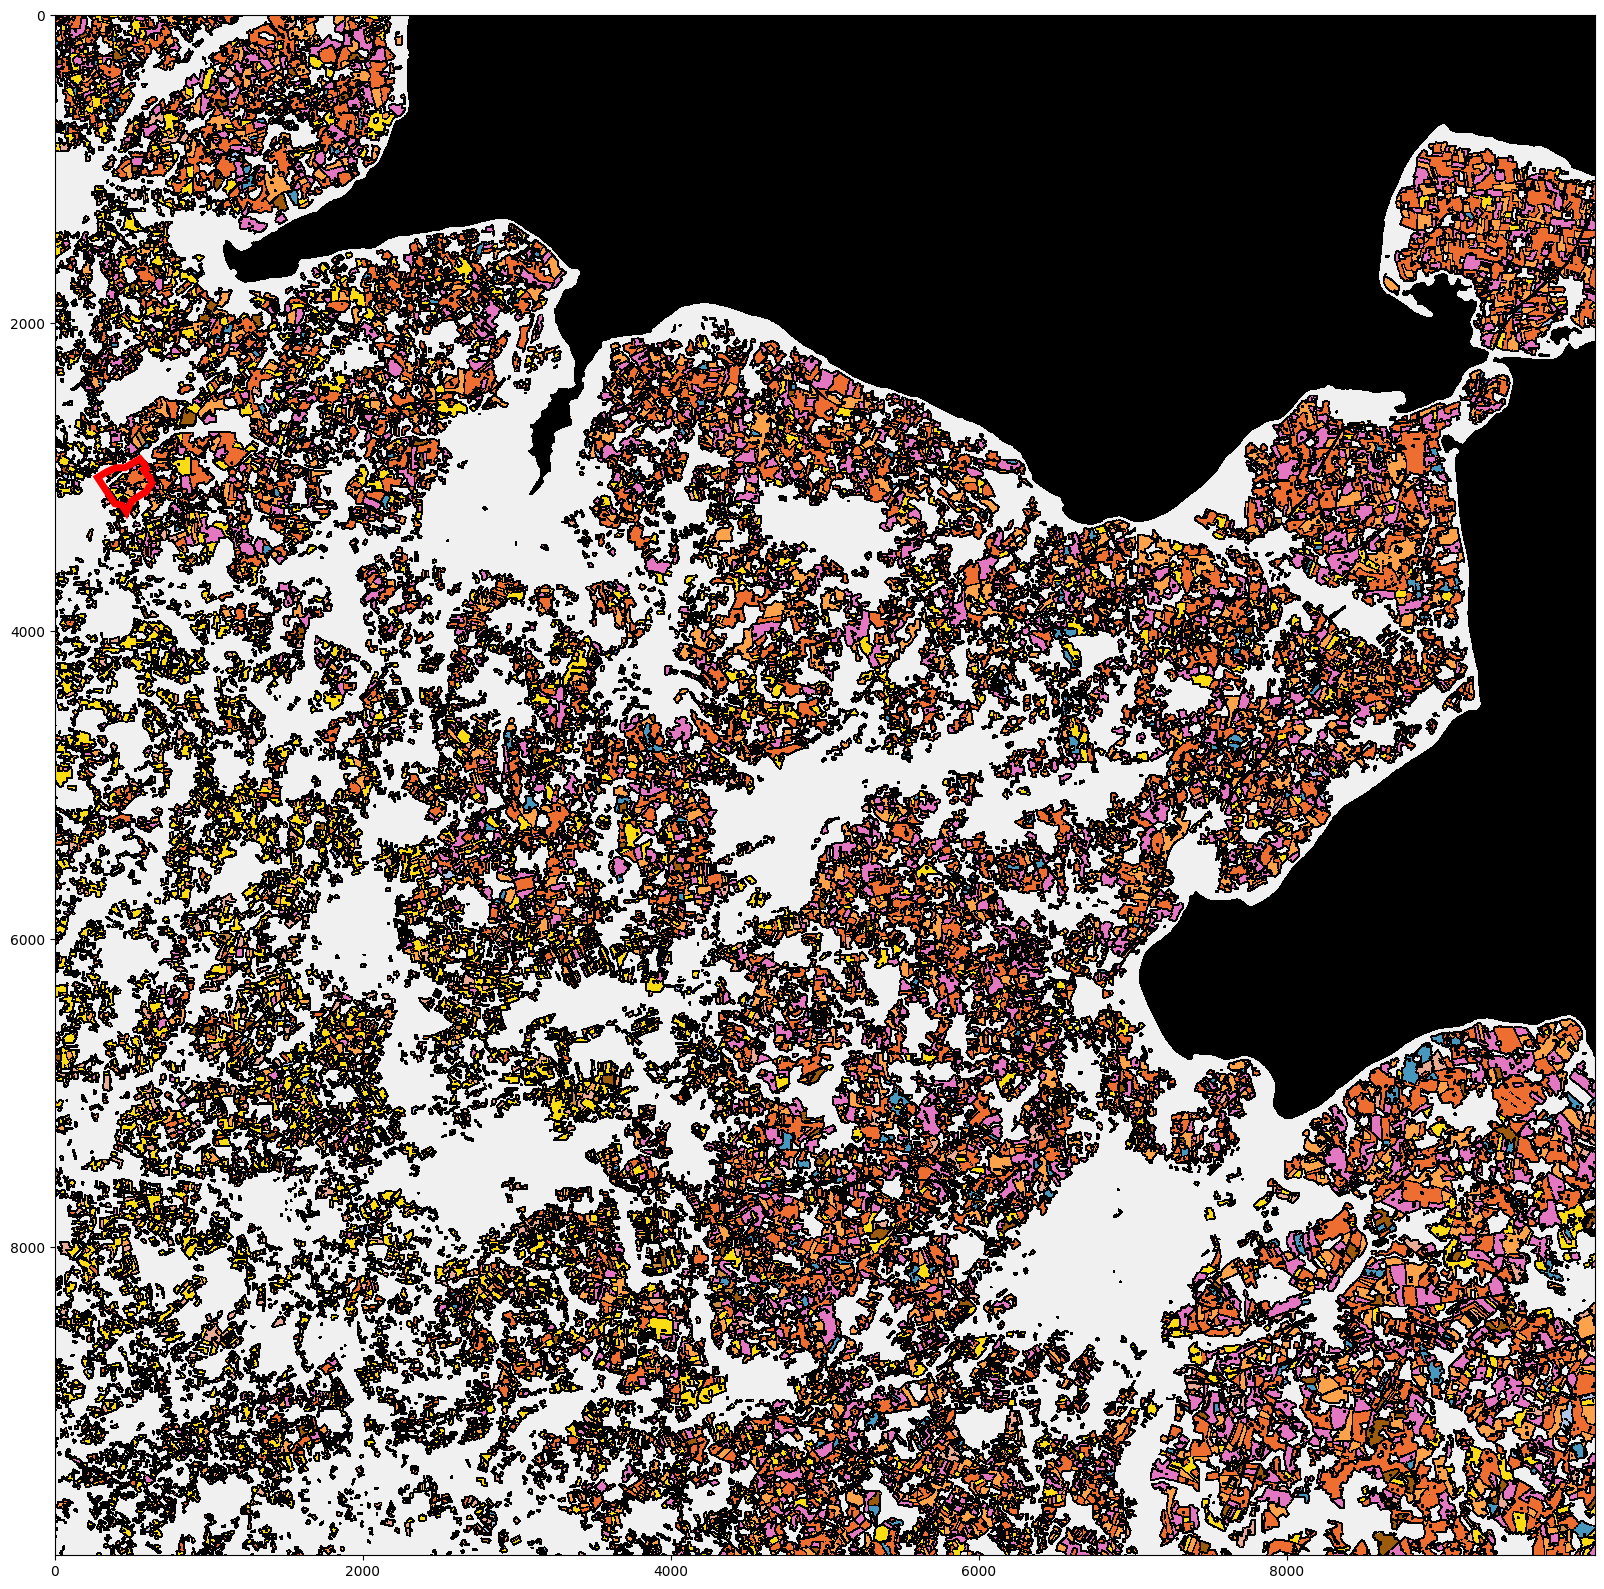

{
  "0": 297080,
  "1110": 14212,
  "1120": 8131,
  "1130": 9005,
  "1150": 1596,
  "1210": 156,
  "1320": 1946,
  "1430": 5983,
  "1440": 57,
  "3100": 106
}


/Users/johannesgille/Desktop/CE_2026_4_drought/.venv/lib/python3.9/site-packages/xarray/core/duck_array_ops.py:237: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [42]:
tile_dict = {}
tile_data = xr.DataArray()
for idx, lau in de_gdf.iterrows():
    lau_geom = lau.geometry
    matches = tile_index.sindex.query(lau_geom, predicate="intersects")    
    
    update_tileset = False
    path_list = tile_index.iloc[matches]["path"].values
    
    # remove tiles that were needed for the previous LAU, but not for this one
    for k, v in tile_dict:
        print("tiledata: ", k, v)
        if k not in path_list:
            del tile_dict[k]
            update_tileset = True
    
    # add new tiles
    for path in path_list:
        if path not in tile_dict:
            print("path: ", path)
            tile_dict[path] = rxr.open_rasterio(path)
            update_tileset = True

    if update_tileset:
        tile_data = xr.concat(tile_dict.values(), dim="band")
    
    fig, ax = plt.subplots(1,1, figsize=(20,20))
    ax.imshow(utils.prep_copernicus_data(np.array(tile_data[0])), utils.get_mpl_cmap(path_list[0]))
    
    
    with rasterio.open(path_list[0]) as src:
        transform = src.transform
    
    coords = list(lau_geom.geoms[0].exterior.coords)
    coords = [world_to_pixel(x, y, transform) for x, y in coords]
    patch = MplPolygon(coords, fill=False, edgecolor="red", linewidth=5) 
    ax.add_patch(patch)
    plt.show()

    if isinstance(lau_geom, Polygon):

        clipped_tile = tile_data.rio.clip(lau_geom, crs)
    elif isinstance(lau_geom, MultiPolygon):
        clipped_tile = tile_data.rio.clip(list(lau_geom.geoms), crs)

    clipped_tile = np.array(clipped_tile)
    clipped_tile = clipped_tile[clipped_tile != 65535]

    # flatten and count
    values, counts = np.unique(clipped_tile, return_counts=True)

    result = dict(zip(values.tolist(), counts.tolist()))
    print(json.dumps(result, indent=2))
        
    break

In [41]:
lau

GISCO_ID                                            DE_01058132
CNTR_CODE                                                    DE
LAU_NAME                                      Rade b. Rendsburg
POP_2024                                                  214.0
POP_DENS_2                                                  NaN
AREA_KM2                                               6.542021
YEAR                                                       2024
geometry      MULTIPOLYGON (((4305992.524477142 3469125.5286...
Name: 11105, dtype: object

In [43]:
lau.geometry.area

6464816.20324744

In [46]:
area = result
del area[0]
print(sum(area.values))

TypeError: 'builtin_function_or_method' object is not iterable

In [ ]:
len(set(candidate_tiles["path"].values))

57

In [17]:
de_geom = unary_union(de_gdf.geometry)

In [15]:

def load_clip(path, geom):
    da = rxr.open_rasterio(path, masked=True)
    return da.rio.clip([geom], crs)


In [20]:
candidate_tiles.path.values

array(['/Users/johannesgille/Desktop/CE_2026_4_drought/data/Crop_Types/CLMS_HRLVLCC_CTY_S2023_R10m_E43N34_03035_V01_R00/CLMS_HRLVLCC_CTY_S2023_R10m_E43N34_03035_V01_R00.tif',
       '/Users/johannesgille/Desktop/CE_2026_4_drought/data/Crop_Types/CLMS_HRLVLCC_CTY_S2023_R10m_E43N34_03035_V01_R00/CLMS_HRLVLCC_CTY_S2023_R10m_E43N34_03035_V01_R00.tif',
       '/Users/johannesgille/Desktop/CE_2026_4_drought/data/Crop_Types/CLMS_HRLVLCC_CTY_S2023_R10m_E42N34_03035_V01_R00/CLMS_HRLVLCC_CTY_S2023_R10m_E42N34_03035_V01_R00.tif',
       ...,
       '/Users/johannesgille/Desktop/CE_2026_4_drought/data/Crop_Types/CLMS_HRLVLCC_CTY_S2023_R10m_E44N30_03035_V01_R00/CLMS_HRLVLCC_CTY_S2023_R10m_E44N30_03035_V01_R00.tif',
       '/Users/johannesgille/Desktop/CE_2026_4_drought/data/Crop_Types/CLMS_HRLVLCC_CTY_S2023_R10m_E44N30_03035_V01_R00/CLMS_HRLVLCC_CTY_S2023_R10m_E44N30_03035_V01_R00.tif',
       '/Users/johannesgille/Desktop/CE_2026_4_drought/data/Crop_Types/CLMS_HRLVLCC_CTY_S2023_R10m_E44N30_03035_V

In [18]:
candidate_tiles_paths = set(candidate_tiles["path"].values)

tile_data = []
for i,t in enumerate(candidate_tiles_paths):
    if i%5 == 0:
        print(f"loading tile {i} of {len(candidate_tiles_paths)}")
    tile_data.append(load_clip(t, de_geom))


loading tile 0 of 57
loading tile 5 of 57
loading tile 10 of 57
loading tile 15 of 57
loading tile 20 of 57
loading tile 25 of 57
loading tile 30 of 57
loading tile 35 of 57
loading tile 40 of 57
loading tile 45 of 57
loading tile 50 of 57
loading tile 55 of 57


In [19]:
tile_data = xr.concat(tile_data, dim="band")


: 

In [26]:
de_gdf.bounds["minx"].min()

np.float64(4031373.8217481286)

In [29]:
import rasterio
from rasterio.windows import from_bounds

arrays = []

bounds = de_gdf.bounds

for _, row in candidate_tiles.iterrows():
    with rasterio.open(row.path) as src:
        window = from_bounds(left=bounds["minx"].min(), bottom=bounds["miny"].min(), right=bounds["maxx"].max(), top=bounds["maxy"].max(), transform=src.transform)
        # window = from_bounds(, transform=src.transform)
        data = src.read(1, window=window)
        arrays.append((data, window, src.transform))


KeyboardInterrupt: 

In [ ]:
from rasterio.merge import merge

datasets = [rasterio.open(row.path) for _, row in candidate_tiles.iterrows()]
merged, merged_transform = merge(datasets, bounds=aoi.bounds)
